In [1]:
import os
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
    precision_score, recall_score,
    roc_curve, auc
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('husl')

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load preprocessed data — same as Week 5
df_train = pd.read_csv('./data/data/processed/train_processed_advanced.csv')
df_test  = pd.read_csv('./data/data/processed/test_processed_advanced.csv')

# Separate features and target
X_signal      = df_train.drop(columns=['attack_class']).values
X_test_signal = df_test.drop(columns=['attack_class']).values

# Encode labels
le       = LabelEncoder()
y_master = le.fit_transform(df_train['attack_class'])
y_test_l = le.transform(df_test['attack_class'])

# Train/Test split — same split as Week 5
X_train, X_test, y_train, y_test = train_test_split(
    X_signal, y_master,
    test_size=0.2, random_state=42, stratify=y_master
)

print(f'Data loaded successfully.')
print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')
print(f'Classes : {le.classes_}')

Data loaded successfully.
X_train : (269372, 34) | X_test : (67343, 34)
Classes : [0 1 2 3 4]


In [3]:
# Hyperparameter tuning — same as Week 5 to get sentinel_brain
param_grid = {
    'n_estimators'    : [50, 100],
    'max_depth'       : [10, 20],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid, cv=3, scoring='f1_macro', verbose=1
)
grid.fit(X_train, y_train)
sentinel_brain = grid.best_estimator_

print(f'Best Hyperparameters : {grid.best_params_}')
print(f'Best CV F1 Score     : {grid.best_score_:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Hyperparameters : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV F1 Score     : 0.9997


In [4]:
models = {
    'Random Forest'    : sentinel_brain,
    'Decision Tree'    : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
                            n_estimators=50, max_depth=3,
                            subsample=0.3, random_state=42),
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss', random_state=42
    )
    print('XGBoost available — included.')
except ImportError:
    print('XGBoost not installed.')

# Train all models and collect results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred        = model.predict(X_test)
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'F1 Macro' : f1_score(y_test, y_pred, average='macro')
    }

print('All models trained.')

XGBoost available — included.
All models trained.


In [5]:
full_results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro')

    full_results[name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1 Score' : f1
    }

    print(f'\n{name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')


Random Forest
  Accuracy  : 0.9997
  Precision : 0.9997
  Recall    : 0.9997
  F1 Score  : 0.9997

Decision Tree
  Accuracy  : 0.9976
  Precision : 0.9976
  Recall    : 0.9976
  F1 Score  : 0.9976

Gradient Boosting
  Accuracy  : 0.9905
  Precision : 0.9905
  Recall    : 0.9905
  F1 Score  : 0.9905

XGBoost
  Accuracy  : 0.9995
  Precision : 0.9995
  Recall    : 0.9995
  F1 Score  : 0.9995


In [11]:
y_pred_best    = sentinel_brain.predict(X_test)
unique_classes = sorted(np.unique(np.concatenate([y_test, y_pred_best])))
class_names    = [['DoS', 'Probe', 'R2L', 'U2R', 'normal'][i] for i in unique_classes]

print('Classification Report — Random Forest')
print(classification_report(y_test, y_pred_best, target_names=class_names))

Classification Report — Random Forest
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     13469
       Probe       1.00      1.00      1.00     13468
         R2L       1.00      1.00      1.00     13469
         U2R       1.00      1.00      1.00     13469
      normal       1.00      1.00      1.00     13468

    accuracy                           1.00     67343
   macro avg       1.00      1.00      1.00     67343
weighted avg       1.00      1.00      1.00     67343



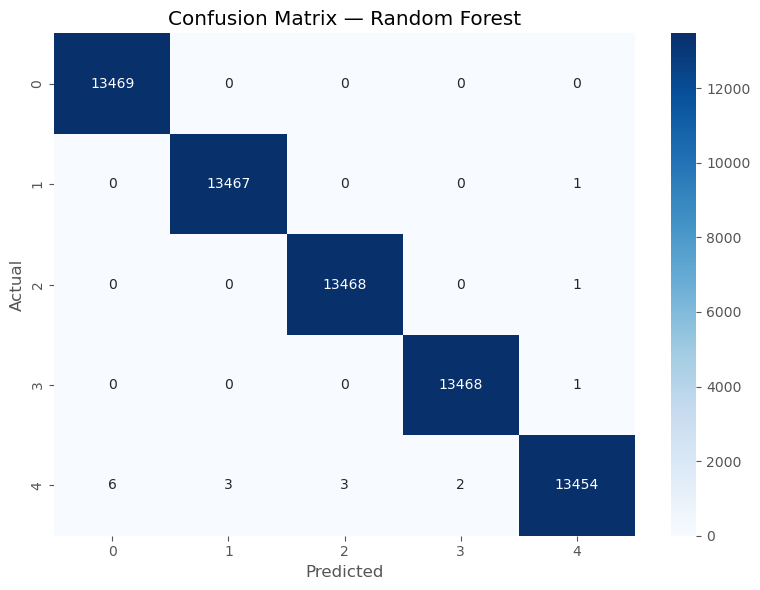

In [12]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

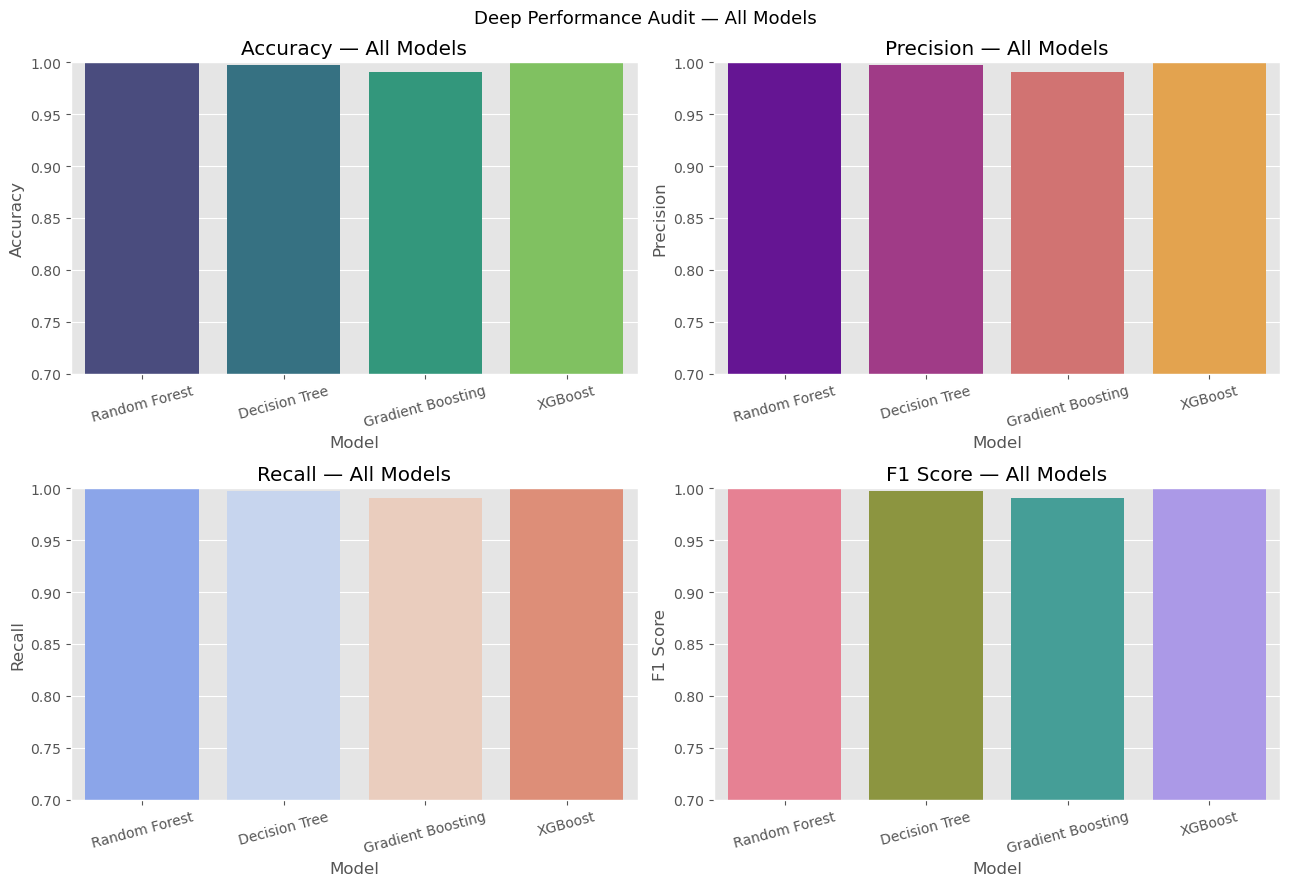

Final Model Rankings (by F1 Score)
            Model  Accuracy  Precision   Recall  F1 Score
    Random Forest  0.999748   0.999748 0.999748  0.999748
          XGBoost  0.999480   0.999480 0.999480  0.999480
    Decision Tree  0.997609   0.997615 0.997609  0.997607
Gradient Boosting  0.990511   0.990518 0.990511  0.990500


In [8]:
# Model Comparison — 4 metrics in a 2x2 grid
full_results_df = pd.DataFrame(full_results).T.reset_index().rename(columns={'index': 'Model'})

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
palettes = ['viridis', 'plasma', 'coolwarm', 'husl']

for ax, metric, palette in zip(axes.flatten(), metrics, palettes):
    sns.barplot(data=full_results_df, x='Model', y=metric, palette=palette, ax=ax)
    ax.set_title(f'{metric} — All Models')
    ax.set_ylim(0.7, 1.0)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Deep Performance Audit — All Models', fontsize=13)
plt.tight_layout()
plt.show()

print('Final Model Rankings (by F1 Score)')
print(full_results_df.sort_values('F1 Score', ascending=False).to_string(index=False))

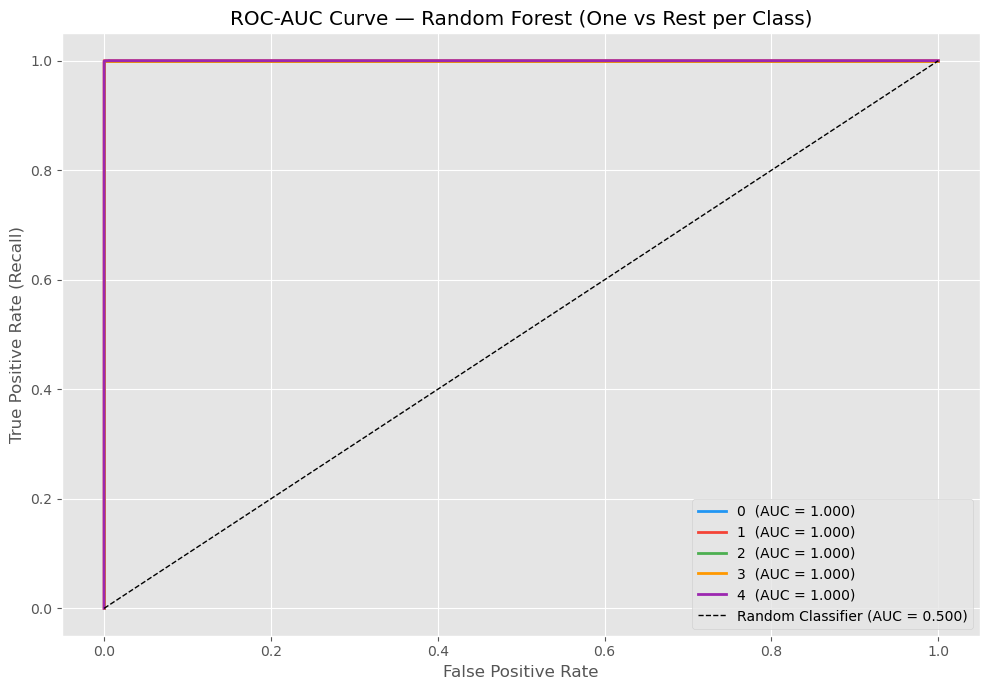

In [9]:
n_classes  = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
y_prob     = sentinel_brain.predict_proba(X_test)

colors_roc = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

plt.figure(figsize=(10, 7))

for i, (cls_name, color) in enumerate(zip(le.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name}  (AUC = {roc_auc:.3f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')

plt.title('ROC-AUC Curve — Random Forest (One vs Rest per Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Cross Validation F1 Scores : [0.9996 0.9997 0.9996 0.9997 0.9997]
Mean CV F1 : 0.9997
Std  CV F1 : 0.0001


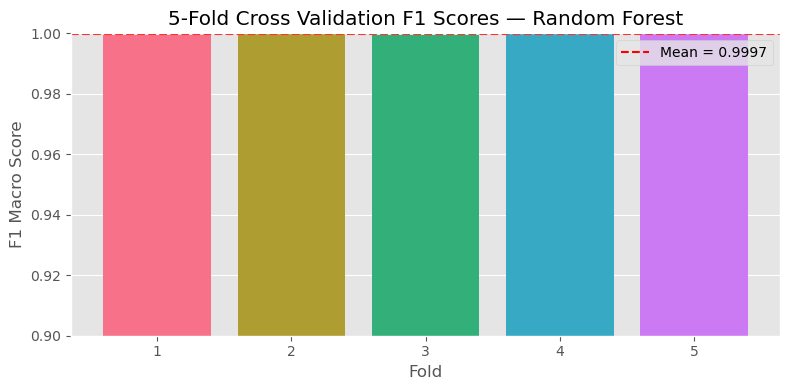

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    sentinel_brain, X_signal, y_master,
    cv=skf, scoring='f1_macro', n_jobs=-1)

print(f'Cross Validation F1 Scores : {cv_scores.round(4)}')
print(f'Mean CV F1 : {cv_scores.mean():.4f}')
print(f'Std  CV F1 : {cv_scores.std():.4f}')

# CV scores bar chart
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color=sns.color_palette('husl', 5))
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross Validation F1 Scores — Random Forest')
plt.xlabel('Fold')
plt.ylabel('F1 Macro Score')
plt.ylim(0.9, 1.0)
plt.legend()
plt.tight_layout()
plt.show()